In [1]:
# 라이브러리 임포트
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

plt.style.use('seaborn-v0_8')
%matplotlib inline

print("라이브러리 로드 완료!")

라이브러리 로드 완료!


In [3]:
# 빗썸에서 BTC 4H 데이터 가져오기
exchange = ccxt.bithumb()

def get_ohlcv(symbol, timeframe='4h', limit=500):
    ohlcv = exchange.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df

df = get_ohlcv('BTC/KRW', timeframe='4h', limit=500)

print(f"데이터 기간: {df.index[0]} ~ {df.index[-1]}")
print(f"데이터 수: {len(df)}개 봉")
print(df.tail())

데이터 기간: 2026-01-20 03:00:00 ~ 2026-04-13 11:00:00
데이터 수: 500개 봉
                            open         high          low        close  \
timestamp                                                                 
2026-04-12 19:00:00  106160000.0  106525000.0  105373000.0  105855000.0   
2026-04-12 23:00:00  105855000.0  106477000.0  105482000.0  106154000.0   
2026-04-13 03:00:00  106169000.0  106228000.0  105700000.0  106000000.0   
2026-04-13 07:00:00  105986000.0  106054000.0  105446000.0  105632000.0   
2026-04-13 11:00:00  105652000.0  107330000.0  105625000.0  107297000.0   

                         volume  
timestamp                        
2026-04-12 19:00:00   65.589823  
2026-04-12 23:00:00   76.399528  
2026-04-13 03:00:00   41.462583  
2026-04-13 07:00:00   44.974340  
2026-04-13 11:00:00  122.267599  


In [4]:
# 지표 계산
def calc_indicators(df, donchian_window=20, atr_window=14):
    df = df.copy()
    
    # ATR
    df['prev_close'] = df['close'].shift(1)
    tr1 = df['high'] - df['low']
    tr2 = (df['high'] - df['prev_close']).abs()
    tr3 = (df['low'] - df['prev_close']).abs()
    df['tr'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['atr'] = df['tr'].rolling(atr_window).mean()
    
    # 돈치안 채널
    df['dc_high'] = df['high'].rolling(donchian_window).max().shift(1)
    df['dc_low'] = df['low'].rolling(donchian_window).min().shift(1)
    
    # RSI
    delta = df['close'].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi'] = 100 - (100 / (1 + gain/loss))
    
    # MA (추세필터)
    df['ma20'] = df['close'].rolling(20).mean()
    df['ma60'] = df['close'].rolling(60).mean()
    
    return df.dropna()

df = calc_indicators(df)
print("지표 계산 완료!")
print(df.tail())

지표 계산 완료!
                            open         high          low        close  \
timestamp                                                                 
2026-04-12 19:00:00  106160000.0  106525000.0  105373000.0  105855000.0   
2026-04-12 23:00:00  105855000.0  106477000.0  105482000.0  106154000.0   
2026-04-13 03:00:00  106169000.0  106228000.0  105700000.0  106000000.0   
2026-04-13 07:00:00  105986000.0  106054000.0  105446000.0  105632000.0   
2026-04-13 11:00:00  105652000.0  107330000.0  105625000.0  107297000.0   

                         volume   prev_close         tr            atr  \
timestamp                                                                
2026-04-12 19:00:00   65.589823  106160000.0  1152000.0  888785.714286   
2026-04-12 23:00:00   76.399528  105855000.0   995000.0  877714.285714   
2026-04-13 03:00:00   41.462583  106154000.0   528000.0  853857.142857   
2026-04-13 07:00:00   44.974340  106000000.0   608000.0  855928.571429   
2026-04-13 11:00:00 

In [6]:
# 백테스팅 엔진
def backtest_donchian(df, 
                       initial_capital=100000,  # 10만원
                       risk_per_trade=0.01,      # 1% 리스크
                       atr_mult=3.0,
                       tp1_r=1.0, tp2_r=2.0,
                       tp1_pct=0.30, tp2_pct=0.30,
                       fee=0.0025):              # 빗썸 수수료 0.25%

    capital = initial_capital
    position = None
    trades = []
    equity_curve = [capital]

    for i in range(1, len(df)):
        row = df.iloc[i]
        price = row['close']
        atr = row['atr']
        dc_high = row['dc_high']
        trend_ok = row['close'] > row['ma60']

        # 포지션 관리
        if position is not None:
            # 트레일링 스탑 업데이트
            position['highest'] = max(position['highest'], price)
            trail_stop = position['highest'] - atr * atr_mult
            position['stop'] = max(position['stop'], trail_stop)

            R = position['entry'] - position['initial_stop']

            # TP1
            if not position['tp1_done'] and price >= position['entry'] + tp1_r * R:
                sell_qty = position['size'] * tp1_pct
                proceeds = sell_qty * price * (1 - fee)
                capital += proceeds
                position['size'] -= sell_qty
                position['tp1_done'] = True

            # TP2
            if not position['tp2_done'] and price >= position['entry'] + tp2_r * R:
                sell_qty = position['size'] * tp2_pct
                proceeds = sell_qty * price * (1 - fee)
                capital += proceeds
                position['size'] -= sell_qty
                position['tp2_done'] = True

            # 스탑아웃
            if price < position['stop']:
                proceeds = position['size'] * price * (1 - fee)
                pnl = proceeds - position['cost']
                trades.append({
                    'entry_time': position['entry_time'],
                    'exit_time': df.index[i],
                    'entry': position['entry'],
                    'exit': price,
                    'pnl': pnl,
                    'result': 'STOP'
                })
                capital += proceeds
                position = None

        # 신규 진입 (돈치안 브레이크아웃)
        if position is None and price > dc_high and trend_ok and atr > 0:
            risk_krw = capital * risk_per_trade
            per_unit_risk = atr * atr_mult
            size = risk_krw / per_unit_risk
            cost = size * price * (1 + fee)

            if cost < capital and cost >= 5000:
                capital -= cost
                initial_stop = price - atr * atr_mult
                position = {
                    'entry': price,
                    'entry_time': df.index[i],
                    'size': size,
                    'cost': cost,
                    'stop': initial_stop,
                    'initial_stop': initial_stop,
                    'highest': price,
                    'tp1_done': False,
                    'tp2_done': False,
                }

        equity_curve.append(capital + (position['size'] * price if position else 0))

    return pd.Series(equity_curve, index=df.index[:len(equity_curve)]), trades

equity, trades = backtest_donchian(df)
print(f"백테스팅 완료! 거래 수: {len(trades)}건")

백테스팅 완료! 거래 수: 5건


=== 백테스팅 결과 ===
초기 자본: 100,000원
최종 자본: 98,906원
총 수익률: -1.1%
총 거래 수: 5건

승률: 0.0%
평균 수익: 없음
평균 손실: -2,557원
최대 수익: -432원
최대 손실: -6,189원

=== 거래 내역 ===
           entry_time           exit_time        entry         exit          pnl result
0 2026-03-02 15:00:00 2026-03-06 15:00:00  100500000.0  100731000.0 -4638.731217   STOP
1 2026-03-09 23:00:00 2026-03-18 11:00:00  102854000.0  105442000.0 -6188.586311   STOP
2 2026-04-01 03:00:00 2026-04-04 19:00:00  103881000.0  102156000.0  -497.258516   STOP
3 2026-04-05 19:00:00 2026-04-07 11:00:00  103543000.0  102446000.0 -1026.508660   STOP
4 2026-04-07 19:00:00 2026-04-12 11:00:00  106850000.0  105574000.0  -432.301302   STOP

최대 낙폭 (MDD): -2.8%


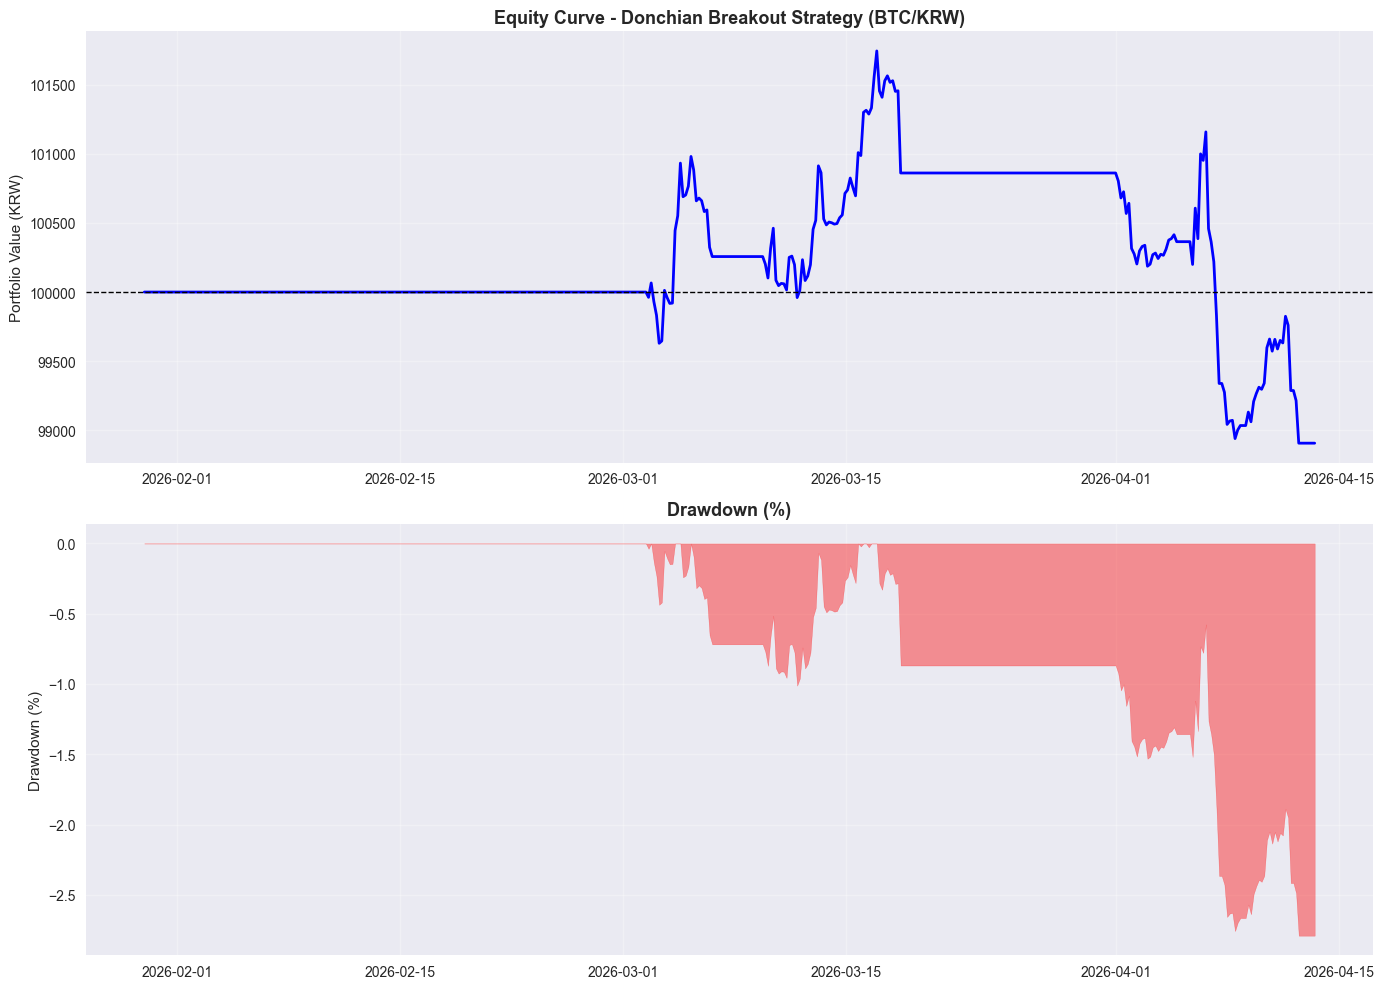

In [7]:
# 백테스팅 결과 분석
initial_capital = 100000

print("=== 백테스팅 결과 ===")
print(f"초기 자본: {initial_capital:,.0f}원")
print(f"최종 자본: {equity.iloc[-1]:,.0f}원")
print(f"총 수익률: {(equity.iloc[-1]/initial_capital - 1)*100:.1f}%")
print(f"총 거래 수: {len(trades)}건")

if trades:
    trades_df = pd.DataFrame(trades)
    wins = trades_df[trades_df['pnl'] > 0]
    losses = trades_df[trades_df['pnl'] < 0]
    
    print(f"\n승률: {len(wins)/len(trades)*100:.1f}%")
    print(f"평균 수익: {wins['pnl'].mean():,.0f}원" if len(wins) > 0 else "평균 수익: 없음")
    print(f"평균 손실: {losses['pnl'].mean():,.0f}원" if len(losses) > 0 else "평균 손실: 없음")
    print(f"최대 수익: {trades_df['pnl'].max():,.0f}원")
    print(f"최대 손실: {trades_df['pnl'].min():,.0f}원")
    
    print("\n=== 거래 내역 ===")
    print(trades_df[['entry_time', 'exit_time', 'entry', 'exit', 'pnl', 'result']].to_string())

# MDD 계산
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max * 100
mdd = drawdown.min()
print(f"\n최대 낙폭 (MDD): {mdd:.1f}%")

# equity curve 차트
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(equity.index, equity, color='blue', linewidth=2)
axes[0].axhline(y=initial_capital, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Equity Curve - Donchian Breakout Strategy (BTC/KRW)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value (KRW)')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4)
axes[1].set_title('Drawdown (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
# 바이낸스에서 BTC/USDT 데이터 가져오기 (더 긴 히스토리)
exchange3 = ccxt.binance()

def get_ohlcv_binance(symbol='BTC/USDT', timeframe='4h', limit=1000):
    ohlcv = exchange3.fetch_ohlcv(symbol, timeframe=timeframe, limit=limit)
    df = pd.DataFrame(ohlcv, columns=['timestamp', 'open', 'high', 'low', 'close', 'volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df

df_binance = get_ohlcv_binance('BTC/USDT', timeframe='4h', limit=1000)
df_binance = calc_indicators(df_binance)

print(f"데이터 기간: {df_binance.index[0]} ~ {df_binance.index[-1]}")
print(f"데이터 수: {len(df_binance)}개 봉")

데이터 기간: 2025-11-07 20:00:00 ~ 2026-04-13 12:00:00
데이터 수: 941개 봉


=== 백테스팅 결과 (BTC/USDT 바이낸스 기준) ===
초기 자본: 100,000원
최종 자본: 91,833원
총 수익률: -8.2%
총 거래 수: 16건
승률: 0.0%
평균 수익: 없음
평균 손실: -4,269원
MDD: -10.2%


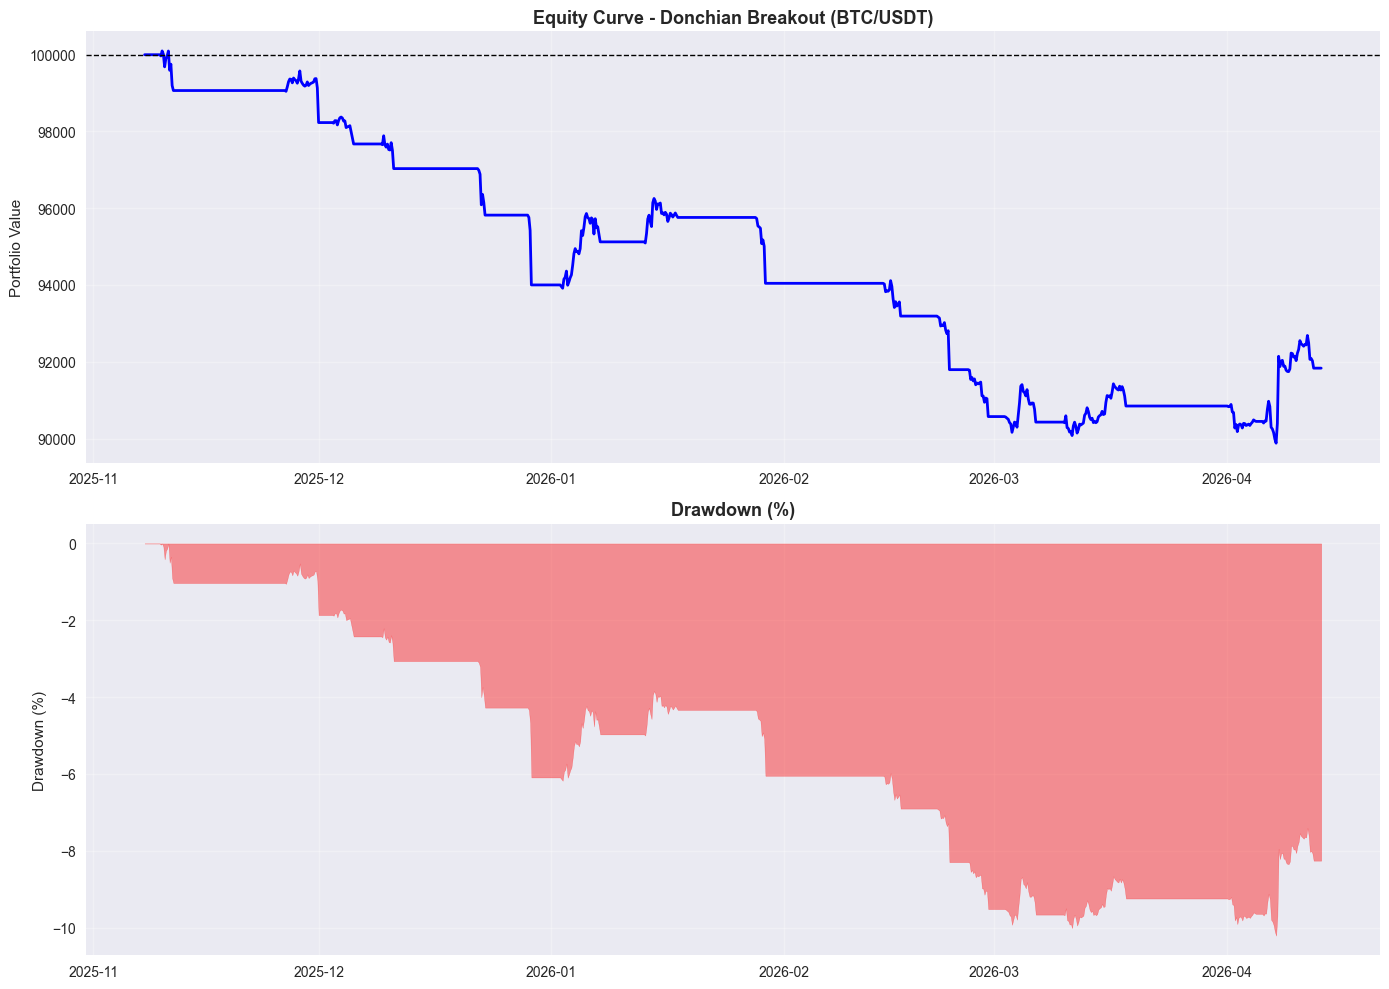

In [10]:
# 바이낸스 데이터로 백테스팅 (수수료 바이낸스 기준 0.1%)
equity_b, trades_b = backtest_donchian(
    df_binance,
    initial_capital=100000,
    risk_per_trade=0.01,
    atr_mult=3.0,
    fee=0.001  # 바이낸스 수수료
)

print("=== 백테스팅 결과 (BTC/USDT 바이낸스 기준) ===")
print(f"초기 자본: 100,000원")
print(f"최종 자본: {equity_b.iloc[-1]:,.0f}원")
print(f"총 수익률: {(equity_b.iloc[-1]/100000 - 1)*100:.1f}%")
print(f"총 거래 수: {len(trades_b)}건")

if trades_b:
    trades_df_b = pd.DataFrame(trades_b)
    wins_b = trades_df_b[trades_df_b['pnl'] > 0]
    losses_b = trades_df_b[trades_df_b['pnl'] < 0]
    
    print(f"승률: {len(wins_b)/len(trades_b)*100:.1f}%")
    print(f"평균 수익: {wins_b['pnl'].mean():,.0f}원" if len(wins_b) > 0 else "평균 수익: 없음")
    print(f"평균 손실: {losses_b['pnl'].mean():,.0f}원" if len(losses_b) > 0 else "평균 손실: 없음")

rolling_max_b = equity_b.cummax()
drawdown_b = (equity_b - rolling_max_b) / rolling_max_b * 100
mdd_b = drawdown_b.min()
print(f"MDD: {mdd_b:.1f}%")

# 차트
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(equity_b.index, equity_b, color='blue', linewidth=2)
axes[0].axhline(y=100000, color='black', linestyle='--', linewidth=1)
axes[0].set_title('Equity Curve - Donchian Breakout (BTC/USDT)', 
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Portfolio Value')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(drawdown_b.index, drawdown_b, 0, color='red', alpha=0.4)
axes[1].set_title('Drawdown (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()